# 05 — Hybrid Ranker (final main logic)

Combines three paradigms — **structural rules**, **lexical retrieval (BM25)**, and **behavioral proof (assessment + engagement)** — under a gate-then-score architecture.

```
Stage 0  HARD EXCLUSION   honeypot -> score = 0
Stage 1  TITLE GATE       x title_tier  (1.0 ... 0.05)   <- traps can't enter
Stage 2  QUALITY SCORE    weighted blend of structured + lexical + behavioral
Stage 3  ENGAGEMENT MULT  x 0.50 ... 1.00 (applied last)

final = title_gate x quality x engagement   (0 if honeypot)
```

**Stage 2 quality blend** (weights sum to 1.0):

| signal | weight | source |
|---|---|---|
| skill depth | 0.25 | rules (02) |
| BM25 lexical (normalized) | 0.20 | lexical (04) |
| career text | 0.18 | rules (02) |
| assessment (proven skill) | 0.17 | forensics (03) |
| career history | 0.10 | rules (02) |
| YoE | 0.06 | rules (02) |
| location | 0.04 | rules (02) |

All sub-scores were already computed in notebooks 02–04 and saved to parquet — here we load, fix the title-taxonomy gap BM25 exposed, normalize BM25, blend, and emit the official submission.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 70)

OUT_DIR = Path('../outputs')
OUT_CSV = OUT_DIR / 'submission_hybrid.csv'

v1  = pd.read_parquet(OUT_DIR / 'scored_v1_full.parquet')
lex = pd.read_parquet(OUT_DIR / 'lexical_scores.parquet')
HONEYPOT_IDS = set(pd.read_csv(OUT_DIR / 'honeypot_ids.csv')['candidate_id'])

df = v1.merge(lex, on='candidate_id', how='left')
print(f'Merged: {df.shape}  | honeypots: {len(HONEYPOT_IDS)}')

Merged: (100000, 47)  | honeypots: 53


## Stage 1 — Title gate (with the taxonomy fix from notebook 04)

BM25 surfaced `Senior Applied Scientist` (ranked #4 lexically) which V1 mis-scored at 0.15. We promote the Applied/Research Scientist family to the strong tier.

In [2]:
# Reuse V1's title score, then patch the Applied/Research Scientist gap to strong (1.0)
APPLIED_STRONG = {
    'applied scientist','senior applied scientist','principal applied scientist',
    'staff applied scientist','research scientist','senior research scientist',
    'machine learning scientist','senior machine learning scientist'
}
df['title_gate'] = df['score_title']
mask = df['title'].str.lower().str.strip().isin(APPLIED_STRONG)
df.loc[mask, 'title_gate'] = 1.0
print(f'Promoted {mask.sum()} Applied/Research Scientist titles to title_gate=1.0')
print('title_gate distribution:')
print(df['title_gate'].value_counts().sort_index(ascending=False).to_string())

Promoted 4 Applied/Research Scientist titles to title_gate=1.0
title_gate distribution:
title_gate
1.00      741
0.80      438
0.40     7680
0.20     8546
0.05    82595


## Normalize BM25 to 0–1 before blending

Raw BM25 runs 0→134 — it would swamp the other 0–1 signals. We normalize by a high quantile (robust to the long tail) and clip.

In [3]:
df['bm25'] = df['bm25'].fillna(0.0)
cap = df['bm25'].quantile(0.999)
df['bm25_norm'] = (df['bm25'] / cap).clip(0, 1)
print(f'BM25 cap (99.9pct) = {cap:.1f}')
print(f"bm25_norm: mean={df['bm25_norm'].mean():.3f}  max={df['bm25_norm'].max():.3f}")
print(f"non-zero bm25_norm: {(df['bm25_norm']>0.01).sum():,}")

BM25 cap (99.9pct) = 72.3
bm25_norm: mean=0.136  max=1.000
non-zero bm25_norm: 95,864


## Stage 2 + assembly — quality blend, then gate × quality × engagement

In [4]:
W = {
    'score_skill':   0.25,
    'bm25_norm':     0.20,
    'score_cartext': 0.18,
    'score_assess':  0.17,
    'score_carhist': 0.10,
    'score_yoe':     0.06,
    'score_loc':     0.04,
}
assert abs(sum(W.values()) - 1.0) < 1e-9, 'weights must sum to 1.0'

df['quality'] = sum(df[col] * w for col, w in W.items())

# honeypot mask (verified list OR inline flag from V1)
df['is_excluded'] = df['candidate_id'].isin(HONEYPOT_IDS) | df['is_honeypot']

df['hybrid_score'] = np.where(
    df['is_excluded'],
    0.0,
    df['title_gate'] * df['quality'] * df['score_eng']
).round(6)

print('Quality blend applied.')
print(f"Excluded (honeypots): {df['is_excluded'].sum()}")
print(f"hybrid_score range: {df['hybrid_score'].min():.4f} -> {df['hybrid_score'].max():.4f}")

Quality blend applied.
Excluded (honeypots): 53
hybrid_score range: 0.0000 -> 0.8884


In [5]:
# Rank: score descending, candidate_id ascending for ties (matches validator rule)
df['score'] = df['hybrid_score'].round(4)
df.sort_values(['score', 'candidate_id'], ascending=[False, True], inplace=True)
df.reset_index(drop=True, inplace=True)
df['hybrid_rank'] = np.arange(1, len(df) + 1)

top100 = df.head(100).copy()
print('=== HYBRID TOP 100 — SAFETY ===')
print(f"Honeypots: {top100['is_excluded'].sum()}  (must be 0)")
print(f"Stuffers:  {top100['is_stuffer'].sum()}  (must be 0)")
print(f"Tier-0:    {top100['is_tier0'].sum()}  (must be 0)")
print(f"Unique scores: {top100['score'].nunique()}/100")
print()
for r in [1,5,10,20,50,100]:
    print(f'  rank {r:3d}: {df["score"].iloc[r-1]:.4f}')

=== HYBRID TOP 100 — SAFETY ===
Honeypots: 0  (must be 0)
Stuffers:  0  (must be 0)
Tier-0:    0  (must be 0)
Unique scores: 100/100

  rank   1: 0.8884
  rank   5: 0.8374
  rank  10: 0.8164
  rank  20: 0.7897
  rank  50: 0.7479
  rank 100: 0.6947


In [6]:
cols = ['hybrid_rank','name','title','country','yoe_claimed','n_tier_c','n_tier_b',
        'mean_assessment','bm25_norm','score_assess','score_skill','score_eng','score']
print('=== HYBRID TOP 20 ===')
top100.head(20)[cols]

=== HYBRID TOP 20 ===


,hybrid_rank,name,title,country,yoe_claimed,n_tier_c,n_tier_b,mean_assessment,bm25_norm,score_assess,score_skill,score_eng,score
0,1,Shreya Tiwari,Senior NLP Engineer,India,7.8,7,4,78.1,1.000000,0.7810,1.0,0.9463,0.8884
1,2,Aarav Trivedi,Senior Machine Learning Engineer,India,7.2,7,6,72.4,1.000000,0.7240,1.0,0.9113,0.8685
2,3,Meera Kumar,Machine Learning Engineer,Canada,4.7,5,3,70.8,1.000000,0.7080,1.0,0.9400,0.8513
3,4,Tanvi Mukherjee,Senior Machine Learning Engineer,India,6.1,7,3,84.0,1.000000,0.8403,1.0,0.8800,0.8420
4,5,Anika Rao,Senior Machine Learning Engineer,UK,8.1,5,6,69.9,1.000000,0.6987,1.0,0.9187,0.8374
5,6,Nisha Pillai,Search Engineer,India,7.6,8,2,69.3,1.000000,0.6930,1.0,0.8875,0.8323
6,7,Aarav Agarwal,Staff Machine Learning Engineer,India,7.0,9,5,63.2,1.000000,0.6320,1.0,0.8888,0.8261
7,8,Ayaan Goyal,NLP Engineer,India,6.5,7,5,69.6,1.000000,0.6958,1.0,0.8800,0.8257
8,9,Riya Chopra,Recommendation Systems Engineer,India,6.0,6,5,62.3,1.000000,0.6230,1.0,0.9225,0.8209
9,10,Sneha Arora,AI Engineer,India,6.9,8,5,73.6,1.000000,0.7362,1.0,0.8712,0.8164


## How the blend reshaped the ranking vs each single method

In [7]:
v1_top   = set(v1.sort_values('score_final', ascending=False).head(100)['candidate_id'])
bm_top   = set(lex.sort_values('bm25', ascending=False).head(100)['candidate_id'])
hy_top   = set(df.head(100)['candidate_id'])

print('Top-100 overlap:')
print(f'  Hybrid ∩ V1(rules): {len(hy_top & v1_top)}/100')
print(f'  Hybrid ∩ BM25:      {len(hy_top & bm_top)}/100')
print(f'  V1 ∩ BM25:          {len(v1_top & bm_top)}/100')
print()
print(f'New in hybrid (not in V1 top100): {len(hy_top - v1_top)}')
new_ids = hy_top - v1_top
if new_ids:
    nd = df[df['candidate_id'].isin(new_ids)][['hybrid_rank','title','country','bm25_norm','mean_assessment','score']]
    print('These entered largely on BM25 / assessment strength:')
    print(nd.head(10).to_string(index=False))

Top-100 overlap:
  Hybrid ∩ V1(rules): 84/100
  Hybrid ∩ BM25:      50/100
  V1 ∩ BM25:          37/100

New in hybrid (not in V1 top100): 16
These entered largely on BM25 / assessment strength:
 hybrid_rank                     title country  bm25_norm  mean_assessment  score
          11  Senior Applied Scientist   India        1.0             74.3 0.8140
          48  Senior Applied Scientist   India        1.0             84.8 0.7494
          73           Search Engineer   India        1.0             80.2 0.7211
          75 Machine Learning Engineer   India        1.0             76.2 0.7202
          76       Applied ML Engineer   India        1.0             71.3 0.7184
          78               AI Engineer   India        1.0             75.3 0.7169
          79       Applied ML Engineer   India        1.0             65.9 0.7141
          82       Applied ML Engineer   India        1.0             75.0 0.7097
          86              NLP Engineer   India        1.0          

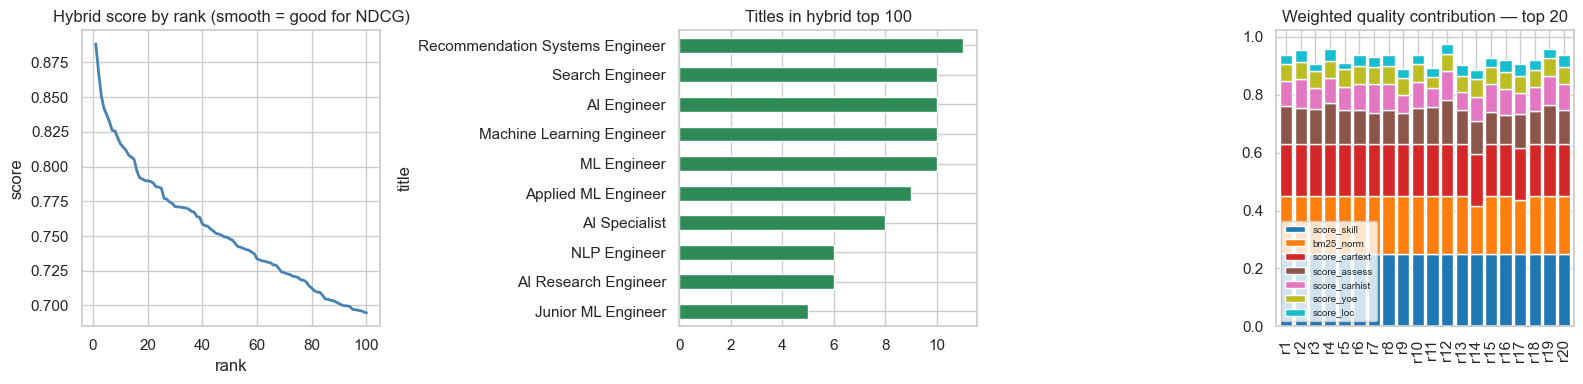

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1,101), df.head(100)['score'].values, color='steelblue', lw=2)
axes[0].set_title('Hybrid score by rank (smooth = good for NDCG)')
axes[0].set_xlabel('rank'); axes[0].set_ylabel('score')

df.head(100)['title'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Titles in hybrid top 100'); axes[1].invert_yaxis()

# component contribution (weighted) for top 20
contrib_cols = {'score_skill':0.25,'bm25_norm':0.20,'score_cartext':0.18,
                'score_assess':0.17,'score_carhist':0.10,'score_yoe':0.06,'score_loc':0.04}
contrib = df.head(20)[list(contrib_cols)].mul(pd.Series(contrib_cols), axis=1)
contrib.index = [f'r{i}' for i in range(1,21)]
contrib.plot(kind='bar', stacked=True, ax=axes[2], colormap='tab10', width=0.85)
axes[2].set_title('Weighted quality contribution — top 20')
axes[2].legend(fontsize=7, loc='lower left'); axes[2].set_xlabel('')
plt.tight_layout(); plt.savefig(OUT_DIR / 'hybrid_overview.png', dpi=120); plt.show()

## Build the official submission (4 columns) and validate

In [9]:
def make_reasoning(r):
    bits = [f"{r['title']} with {float(r['yoe_claimed']):.1f} yrs"]
    bits.append(f"{int(r['n_tier_c'])} core + {int(r['n_tier_b'])} applied AI skills")
    if pd.notna(r['mean_assessment']):
        bits.append(f"assessed skill {float(r['mean_assessment']):.0f}/100")
    if r['bm25_norm'] > 0.3:
        bits.append('strong JD-text match')
    if not r['is_consulting']:
        bits.append('product company')
    rr = r['response_rate']
    if pd.notna(rr):
        bits.append(f"response rate {float(rr):.2f}")
    return ('; '.join(bits) + '.').replace('\n', ' ').strip()

sub = df.head(100).copy()
sub['rank'] = np.arange(1, 101)
sub['reasoning'] = sub.apply(make_reasoning, axis=1)
submission = sub[['candidate_id', 'rank', 'score', 'reasoning']]
submission.to_csv(OUT_CSV, index=False, encoding='utf-8', float_format='%.4f')
print(f'Saved -> {OUT_CSV}')
print(submission.head(8).to_string(index=False))

Saved -> ..\outputs\submission_hybrid.csv
candidate_id  rank  score                                                                                                                                                      reasoning
CAND_0011687     1 0.8884              Senior NLP Engineer with 7.8 yrs; 7 core + 4 applied AI skills; assessed skill 78/100; strong JD-text match; product company; response rate 0.89.
CAND_0018499     2 0.8685 Senior Machine Learning Engineer with 7.2 yrs; 7 core + 6 applied AI skills; assessed skill 72/100; strong JD-text match; product company; response rate 0.61.
CAND_0040887     3 0.8513        Machine Learning Engineer with 4.7 yrs; 5 core + 3 applied AI skills; assessed skill 71/100; strong JD-text match; product company; response rate 0.84.
CAND_0046525     4 0.8420 Senior Machine Learning Engineer with 6.1 yrs; 7 core + 3 applied AI skills; assessed skill 84/100; strong JD-text match; product company; response rate 0.88.
CAND_0055905     5 0.8374 Senior 

In [10]:
# Inline validation mirroring validate_submission.py
import csv, re
REQUIRED = ['candidate_id','rank','score','reasoning']
PAT = re.compile(r'^CAND_[0-9]{7}$')
rows = list(csv.reader(open(OUT_CSV, encoding='utf-8', newline='')))
hdr, data = rows[0], [r for r in rows[1:] if any(c.strip() for c in r)]
err = []
if hdr != REQUIRED: err.append(f'header {hdr}')
if len(data) != 100: err.append(f'{len(data)} rows')
seen_r, by_rank = set(), []
for i, c in enumerate(data):
    cid, rk, sc, _ = c
    if not PAT.match(cid): err.append(f'row{i+2} id {cid}')
    rk = int(rk); seen_r.add(rk); by_rank.append((rk, float(sc), cid))
if set(range(1,101)) - seen_r: err.append('missing ranks')
by_rank.sort()
for a, b in zip(by_rank, by_rank[1:]):
    if a[1] < b[1]: err.append('score increased')
    if a[1] == b[1] and a[2] > b[2]: err.append('tie-break')
sub_ids = {c[0] for c in data}
print(f"Honeypots in submission: {len(sub_ids & HONEYPOT_IDS)}")
print('VALIDATION:', 'PASSED' if not err else f'FAILED {err[:5]}')

Honeypots in submission: 0
VALIDATION: PASSED


In [11]:
# Persist full hybrid scoring for audit / submission_metadata
df.to_parquet(OUT_DIR / 'scored_hybrid_full.parquet', index=False)
print('Saved -> outputs/scored_hybrid_full.parquet', df.shape)

print('\n' + '='*60)
print('HYBRID — SUMMARY')
print('='*60)
print(f"Top 100: {df.head(100)['is_excluded'].sum()} honeypots, "
      f"{df.head(100)['is_stuffer'].sum()} stuffers, "
      f"{df.head(100)['score'].nunique()} unique scores")
print(f"Score: rank1={df['score'].iloc[0]:.4f}  rank100={df['score'].iloc[99]:.4f}")
print(f"Countries: {dict(df.head(100)['country'].value_counts())}")
print('\nFinal submission -> outputs/submission_hybrid.csv (official 4-col format)')

Saved -> outputs/scored_hybrid_full.parquet (100000, 54)

HYBRID — SUMMARY
Top 100: 0 honeypots, 0 stuffers, 100 unique scores
Score: rank1=0.8884  rank100=0.6947
Countries: {'India': np.int64(89), 'Canada': np.int64(3), 'Australia': np.int64(2), 'USA': np.int64(2), 'Germany': np.int64(2), 'UK': np.int64(1), 'Singapore': np.int64(1)}

Final submission -> outputs/submission_hybrid.csv (official 4-col format)
